In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Sangrur_Project/Sangrur_Block_Daily_Rainfall_2010_2025.csv"
)

df.head()

,system:index,block,date,rainfall_mm,.geo
0,20100101_00000000000000000000,Dhuri,2010-01-01,0.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,20100101_00000000000000000001,Lehra,2010-01-01,0.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,20100101_00000000000000000002,Malerkotla,2010-01-01,0.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,20100101_00000000000000000003,Moonak,2010-01-01,0.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,20100101_00000000000000000004,Sangrur,2010-01-01,0.0,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nBlocks:")
print(df["block"].unique())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())


Shape: (35064, 5)

Columns:
['system:index', 'block', 'date', 'rainfall_mm', '.geo']

Blocks:
['Dhuri' 'Lehra' 'Malerkotla' 'Moonak' 'Sangrur' 'Sunam']

Date range:
2010-01-01 to 2025-12-31


In [5]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["block", "date"])

df = df[["date", "block", "rainfall_mm"]]

print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 35064 entries, 0 to 35063
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         35064 non-null  datetime64[ns]
 1   block        35064 non-null  object        
 2   rainfall_mm  35064 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.1+ MB
None

Missing values:
date           0
block          0
rainfall_mm    0
dtype: int64


In [6]:
df["rain_3d"] = (
    df.groupby("block")["rainfall_mm"]
      .transform(lambda x: x.rolling(3).sum())
)

df["rain_7d"] = (
    df.groupby("block")["rainfall_mm"]
      .transform(lambda x: x.rolling(7).sum())
)

df["rain_14d"] = (
    df.groupby("block")["rainfall_mm"]
      .transform(lambda x: x.rolling(14).sum())
)

df["rain_30d"] = (
    df.groupby("block")["rainfall_mm"]
      .transform(lambda x: x.rolling(30).sum())
)

In [7]:
df["dry_day"] = (df["rainfall_mm"] < 1.0).astype(int)

df["dry_days_7d"] = (
    df.groupby("block")["dry_day"]
      .transform(lambda x: x.rolling(7).sum())
)

df["dry_days_14d"] = (
    df.groupby("block")["dry_day"]
      .transform(lambda x: x.rolling(14).sum())
)

df[["date", "block", "rainfall_mm", "rain_7d", "dry_days_7d"]].head(15)


,date,block,rainfall_mm,rain_7d,dry_days_7d
0,2010-01-01,Dhuri,0.000000,NaN,NaN
6,2010-01-02,Dhuri,0.000289,NaN,NaN
12,2010-01-03,Dhuri,0.798230,NaN,NaN
18,2010-01-04,Dhuri,0.000013,NaN,NaN
24,2010-01-05,Dhuri,0.000000,NaN,NaN
30,2010-01-06,Dhuri,0.000000,NaN,NaN
36,2010-01-07,Dhuri,0.000000,0.798532,7.0
42,2010-01-08,Dhuri,0.000000,0.798532,7.0
48,2010-01-09,Dhuri,0.000000,0.798243,7.0
54,2010-01-10,Dhuri,0.000000,0.000013,7.0


In [8]:
df["future_7d_rain"] = (
    df.groupby("block")["rainfall_mm"]
      .transform(lambda x: x.shift(-1).rolling(7).sum())
)

df["dry_spell_next_7d"] = (
    df["future_7d_rain"] < 7
).astype(int)

print(df["dry_spell_next_7d"].value_counts())

dry_spell_next_7d
1    23195
0    11869
Name: count, dtype: int64


In [9]:
features = [
    "rain_3d",
    "rain_7d",
    "rain_14d",
    "rain_30d",
    "dry_days_7d",
    "dry_days_14d"
]

df_model = df.dropna(
    subset=features + ["dry_spell_next_7d"]
).copy()

print("Rows available for training:", len(df_model))

Rows available for training: 34890


In [10]:
train = df_model[df_model["date"] < "2023-01-01"]
test = df_model[df_model["date"] >= "2023-01-01"]

X_train = train[features]
y_train = train["dry_spell_next_7d"]

X_test = test[features]
y_test = test["dry_spell_next_7d"]

print("Training rows:", len(train))
print("Testing rows:", len(test))

Training rows: 28314
Testing rows: 6576


In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
y_pred = model.predict(X_test)

print("Predictions generated!")

Predictions generated!


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 95.97%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2205
           1       0.96      0.98      0.97      4371

    accuracy                           0.96      6576
   macro avg       0.96      0.95      0.95      6576
weighted avg       0.96      0.96      0.96      6576



Confusion Matrix:
[[2042  163]
 [ 102 4269]]


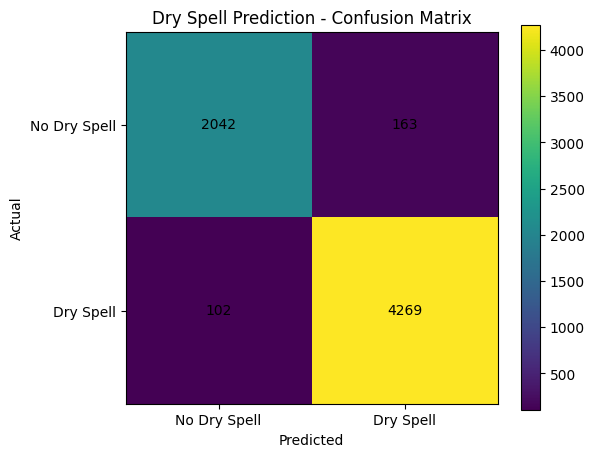

In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Dry Spell Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Dry Spell", "Dry Spell"])
plt.yticks([0, 1], ["No Dry Spell", "Dry Spell"])
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.show()

In [15]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

rain_7d         0.388500
dry_days_7d     0.241138
rain_3d         0.168560
rain_14d        0.121399
rain_30d        0.041277
dry_days_14d    0.039126
dtype: float64


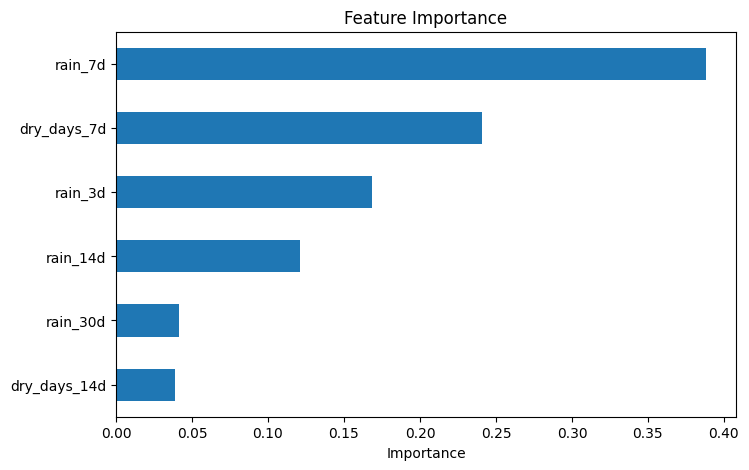

In [16]:
importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [17]:
probabilities = model.predict_proba(X_test)

test_results = test[["date", "block"]].copy()

test_results["dry_spell_probability"] = probabilities[:, 1]

test_results["prediction"] = y_pred

test_results.head(10)

,date,block,dry_spell_probability,prediction
28488,2023-01-01,Dhuri,0.995,1
28494,2023-01-02,Dhuri,1.000,1
28500,2023-01-03,Dhuri,1.000,1
28506,2023-01-04,Dhuri,1.000,1
28512,2023-01-05,Dhuri,0.790,1
28518,2023-01-06,Dhuri,0.995,1
28524,2023-01-07,Dhuri,0.995,1
28530,2023-01-08,Dhuri,0.955,1
28536,2023-01-09,Dhuri,1.000,1
28542,2023-01-10,Dhuri,0.975,1


In [18]:
def risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Moderate"
    else:
        return "High"


test_results["risk"] = test_results["dry_spell_probability"].apply(risk_level)

test_results.head(10)

,date,block,dry_spell_probability,prediction,risk
28488,2023-01-01,Dhuri,0.995,1,High
28494,2023-01-02,Dhuri,1.000,1,High
28500,2023-01-03,Dhuri,1.000,1,High
28506,2023-01-04,Dhuri,1.000,1,High
28512,2023-01-05,Dhuri,0.790,1,High
28518,2023-01-06,Dhuri,0.995,1,High
28524,2023-01-07,Dhuri,0.995,1,High
28530,2023-01-08,Dhuri,0.955,1,High
28536,2023-01-09,Dhuri,1.000,1,High
28542,2023-01-10,Dhuri,0.975,1,High


In [19]:
latest_date = test_results["date"].max()

latest_predictions = test_results[
    test_results["date"] == latest_date
].copy()

latest_predictions = latest_predictions.sort_values(
    "dry_spell_probability",
    ascending=False
)

latest_predictions

,date,block,dry_spell_probability,prediction,risk
35058,2025-12-31,Dhuri,1.000,1,High
35059,2025-12-31,Lehra,1.000,1,High
35061,2025-12-31,Moonak,1.000,1,High
35062,2025-12-31,Sangrur,1.000,1,High
35063,2025-12-31,Sunam,1.000,1,High
35060,2025-12-31,Malerkotla,0.965,1,High


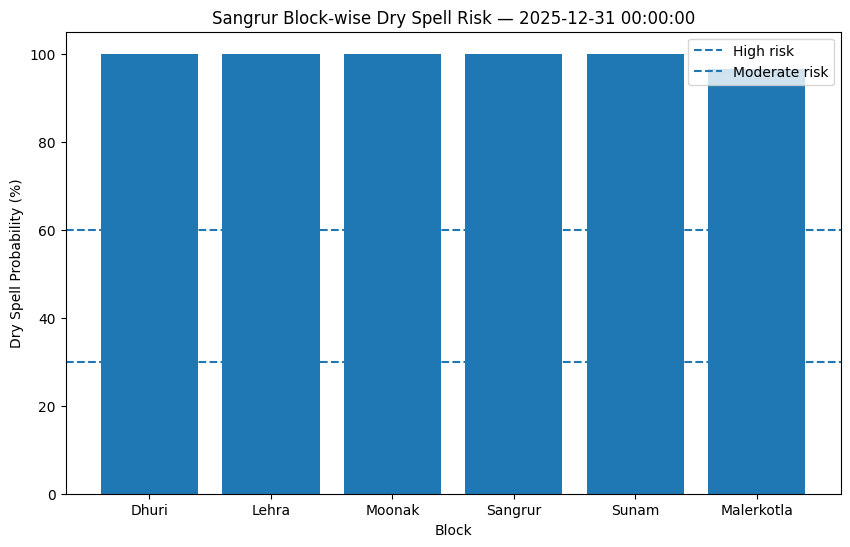

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(
    latest_predictions["block"],
    latest_predictions["dry_spell_probability"] * 100
)

plt.axhline(60, linestyle="--", label="High risk")
plt.axhline(30, linestyle="--", label="Moderate risk")

plt.ylabel("Dry Spell Probability (%)")
plt.xlabel("Block")
plt.title(f"Sangrur Block-wise Dry Spell Risk — {latest_date}")

plt.legend()
plt.show()

In [21]:
!pip -q install geopandas

In [22]:
import zipfile
import os

zip_name = "/content/drive/MyDrive/Sangrur_Project/Sangrur_Blocks.zip"

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("sangrur_shp")

print("Shapefile extracted successfully!")

Shapefile extracted successfully!


In [23]:
import geopandas as gpd
import zipfile
import os

zip_name = "/content/drive/MyDrive/Sangrur_Project/Sangrur_Blocks.zip"

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("sangrur_shp")

shp_file = [
    os.path.join("sangrur_shp", f)
    for f in os.listdir("sangrur_shp")
    if f.endswith(".shp")
][0]

blocks_geo = gpd.read_file(shp_file)

print("Columns:", blocks_geo.columns.tolist())
print("\nBlocks:")
print(blocks_geo[["b_name"]])

Columns: ['s_name', 's_code', 'd_name', 'd_code', 'b_name', 'b_code', 'geometry']

Blocks:
       b_name
0       Dhuri
1       Lehra
2  Malerkotla
3      Moonak
4     Sangrur
5       Sunam


In [24]:
map_data = blocks_geo.merge(
    latest_predictions,
    left_on="b_name",
    right_on="block",
    how="inner"
)

print(map_data[["b_name", "dry_spell_probability", "risk"]])

       b_name  dry_spell_probability  risk
0       Dhuri                  1.000  High
1       Lehra                  1.000  High
2  Malerkotla                  0.965  High
3      Moonak                  1.000  High
4     Sangrur                  1.000  High
5       Sunam                  1.000  High


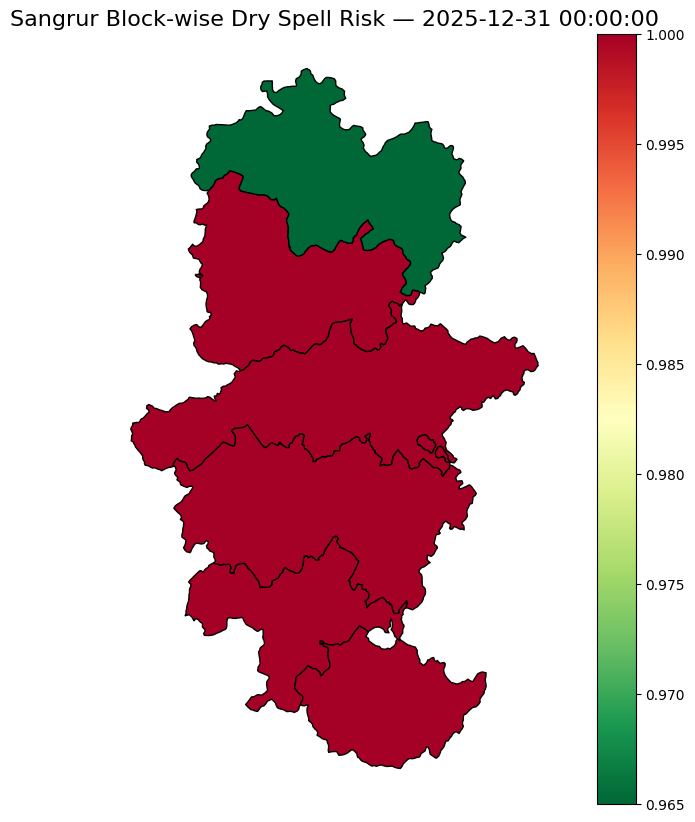

In [25]:
fig, ax = plt.subplots(figsize=(10, 10))

map_data.plot(
    column="dry_spell_probability",
    ax=ax,
    legend=True,
    cmap="RdYlGn_r",
    edgecolor="black"
)

ax.set_title(
    f"Sangrur Block-wise Dry Spell Risk — {latest_date}",
    fontsize=16
)

ax.axis("off")

plt.show()

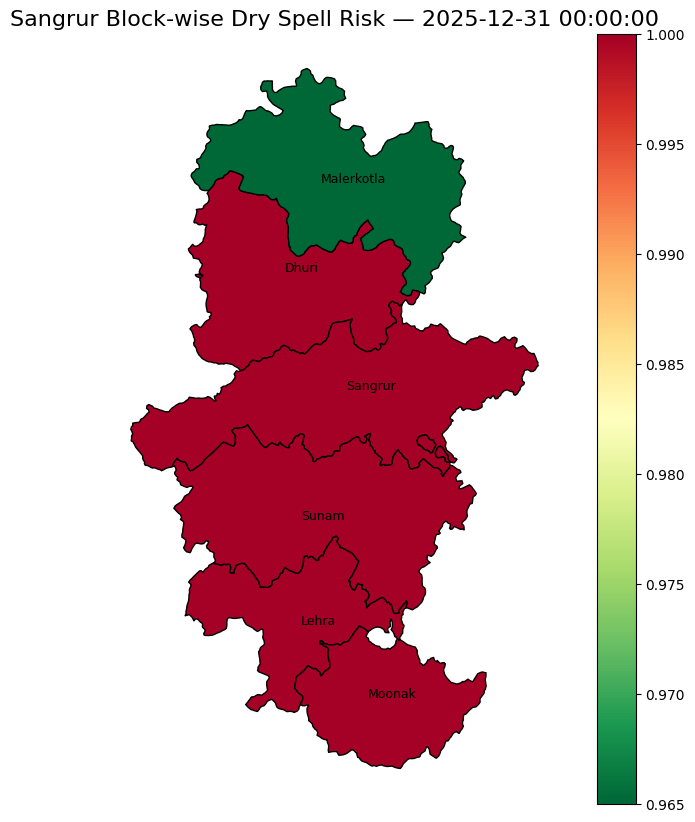

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))

map_data.plot(
    column="dry_spell_probability",
    ax=ax,
    legend=True,
    cmap="RdYlGn_r",
    edgecolor="black"
)

for _, row in map_data.iterrows():
    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["b_name"],
        fontsize=9,
        ha="center"
    )

ax.set_title(
    f"Sangrur Block-wise Dry Spell Risk — {latest_date}",
    fontsize=16
)

ax.axis("off")

plt.show()

In [27]:
print(
    latest_predictions[
        ["block", "dry_spell_probability", "risk"]
    ].to_string(index=False)
)

     block  dry_spell_probability risk
     Dhuri                  1.000 High
     Lehra                  1.000 High
    Moonak                  1.000 High
   Sangrur                  1.000 High
     Sunam                  1.000 High
Malerkotla                  0.965 High


In [28]:
latest_predictions["probability_percent"] = (
    latest_predictions["dry_spell_probability"] * 100
).round(1)

latest_predictions[
    ["block", "probability_percent", "risk"]
]

,block,probability_percent,risk
35058,Dhuri,100.0,High
35059,Lehra,100.0,High
35061,Moonak,100.0,High
35062,Sangrur,100.0,High
35063,Sunam,100.0,High
35060,Malerkotla,96.5,High


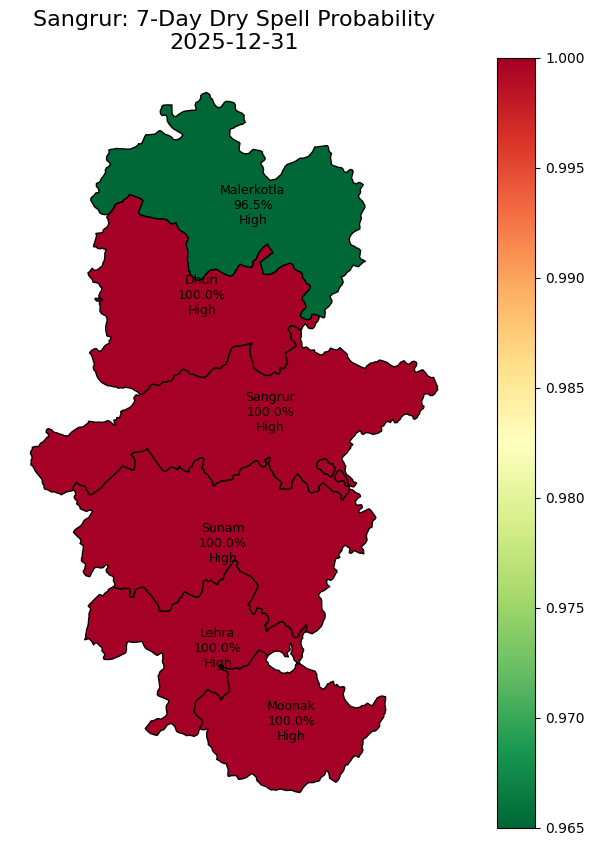

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))

map_data.plot(
    column="dry_spell_probability",
    ax=ax,
    legend=True,
    cmap="RdYlGn_r",
    edgecolor="black"
)

for _, row in map_data.iterrows():
    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        f"{row['b_name']}\n"
        f"{row['dry_spell_probability']*100:.1f}%\n"
        f"{row['risk']}",
        fontsize=9,
        ha="center",
        va="center"
    )

ax.set_title(
    f"Sangrur: 7-Day Dry Spell Probability\n{latest_date.date()}",
    fontsize=16
)

ax.axis("off")
plt.show()

In [30]:
def predict_for_date(date):
    date = pd.to_datetime(date)

    day_data = df_model[df_model["date"] == date].copy()

    if day_data.empty:
        print("No data available for this date.")
        return None

    X_day = day_data[features]

    probabilities = model.predict_proba(X_day)[:, 1]

    results = day_data[["date", "block"]].copy()
    results["dry_spell_probability"] = probabilities
    results["probability_%"] = (probabilities * 100).round(1)

    results["risk"] = results["dry_spell_probability"].apply(risk_level)

    return results.sort_values(
        "dry_spell_probability",
        ascending=False
    )

In [31]:
date_to_test = input(
    "Enter a date (YYYY-MM-DD): "
)

prediction = predict_for_date(date_to_test)

prediction

Enter a date (YYYY-MM-DD): 2026-01-03
No data available for this date.


In [33]:
!pip -q install rasterio


In [34]:
!pip -q install rasterio rasterstats

In [35]:
import rasterio
import geopandas as gpd
from rasterstats import zonal_stats

soil_folder = "/content/drive/MyDrive/Sangrur_Project"

forecast_file = soil_folder + "/c3g_2026.08.30.tif"

In [36]:
shp_file = [
    os.path.join("sangrur_shp", f)
    for f in os.listdir("sangrur_shp")
    if f.endswith(".shp")
][0]

blocks_geo = gpd.read_file(shp_file)

print(blocks_geo[["b_name"]])

       b_name
0       Dhuri
1       Lehra
2  Malerkotla
3      Moonak
4     Sangrur
5       Sunam


In [37]:
with rasterio.open(forecast_file) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Resolution: (0.05000000074505806, 0.05000000074505806)
Bounds: BoundingBox(left=-180.0, bottom=-60.00000178813934, right=180.00000536441803, top=60.0)
NoData: None


In [39]:
with rasterio.open(forecast_file) as src:

    blocks_for_raster = blocks_geo.to_crs(src.crs)

    stats = zonal_stats(
        blocks_for_raster,
        forecast_file,
        stats=["mean", "min", "max"],
        nodata=src.nodata
    )

forecast_results = blocks_geo[["b_name"]].copy()

forecast_results["forecast_mean_mm"] = [
    s["mean"] for s in stats
]

forecast_results["forecast_min_mm"] = [
    s["min"] for s in stats
]

forecast_results["forecast_max_mm"] = [
    s["max"] for s in stats
]

print(forecast_results)

       b_name  forecast_mean_mm  forecast_min_mm  forecast_max_mm
0       Dhuri         11.701832        10.416726        12.625559
1       Lehra         11.147068         7.854357        14.487658
2  Malerkotla         10.767356         9.473828        15.074427
3      Moonak         11.249827         7.760108        14.943795
4     Sangrur         11.538124         9.078489        14.341126
5       Sunam         10.502922         7.606662        13.665714


In [41]:
latest_date = df["date"].max()

recent_data = df[
    df["date"] <= latest_date
].copy()

print("Latest historical date:", latest_date)

Latest historical date: 2025-12-31 00:00:00


In [42]:
recent_features = (
    recent_data
    .groupby("block")
    .tail(30)
)

recent_features = recent_features.groupby("block").agg(
    rain_3d=("rainfall_mm", lambda x: x.tail(3).sum()),
    rain_7d=("rainfall_mm", lambda x: x.tail(7).sum()),
    rain_14d=("rainfall_mm", lambda x: x.tail(14).sum()),
    rain_30d=("rainfall_mm", lambda x: x.tail(30).sum())
).reset_index()

print(recent_features)

        block   rain_3d   rain_7d  rain_14d  rain_30d
0       Dhuri  0.092780  0.092847  0.239766  1.087133
1       Lehra  0.000000  0.000000  0.000000  2.883994
2  Malerkotla  0.381735  0.382395  1.015011  2.455762
3      Moonak  0.000000  0.000000  0.000000  2.290866
4     Sangrur  0.307593  0.318668  0.472275  2.806018
5       Sunam  0.008677  0.008684  0.008684  3.719026


In [43]:
recent_data["dry_day"] = (
    recent_data["rainfall_mm"] < 1.0
).astype(int)

dry_features = (
    recent_data
    .groupby("block")
    .tail(14)
    .groupby("block")["dry_day"]
    .sum()
    .reset_index(name="dry_days_14d")
)

recent_features = recent_features.merge(
    dry_features,
    on="block"
)

recent_features["dry_days_7d"] = (
    recent_data
    .groupby("block")
    .tail(7)
    .groupby("block")["dry_day"]
    .sum()
    .values
)

print(recent_features)

        block   rain_3d   rain_7d  rain_14d  rain_30d  dry_days_14d  \
0       Dhuri  0.092780  0.092847  0.239766  1.087133            14   
1       Lehra  0.000000  0.000000  0.000000  2.883994            14   
2  Malerkotla  0.381735  0.382395  1.015011  2.455762            14   
3      Moonak  0.000000  0.000000  0.000000  2.290866            14   
4     Sangrur  0.307593  0.318668  0.472275  2.806018            14   
5       Sunam  0.008677  0.008684  0.008684  3.719026            14   

   dry_days_7d  
0            7  
1            7  
2            7  
3            7  
4            7  
5            7  


In [44]:
live_data = recent_features.merge(
    forecast_results[["b_name", "forecast_mean_mm"]],
    left_on="block",
    right_on="b_name",
    how="inner"
)

print(live_data)

        block   rain_3d   rain_7d  rain_14d  rain_30d  dry_days_14d  \
0       Dhuri  0.092780  0.092847  0.239766  1.087133            14   
1       Lehra  0.000000  0.000000  0.000000  2.883994            14   
2  Malerkotla  0.381735  0.382395  1.015011  2.455762            14   
3      Moonak  0.000000  0.000000  0.000000  2.290866            14   
4     Sangrur  0.307593  0.318668  0.472275  2.806018            14   
5       Sunam  0.008677  0.008684  0.008684  3.719026            14   

   dry_days_7d      b_name  forecast_mean_mm  
0            7       Dhuri         11.701832  
1            7       Lehra         11.147068  
2            7  Malerkotla         10.767356  
3            7      Moonak         11.249827  
4            7     Sangrur         11.538124  
5            7       Sunam         10.502922  


In [45]:
X_live = live_data[features]

live_data["dry_spell_probability"] = (
    model.predict_proba(X_live)[:, 1]
)

live_data["probability_%"] = (
    live_data["dry_spell_probability"] * 100
).round(1)

live_data["risk"] = (
    live_data["dry_spell_probability"]
    .apply(risk_level)
)

print(
    live_data[
        ["block", "forecast_mean_mm",
         "probability_%", "risk"]
    ]
)

        block  forecast_mean_mm  probability_%  risk
0       Dhuri         11.701832          100.0  High
1       Lehra         11.147068          100.0  High
2  Malerkotla         10.767356           96.5  High
3      Moonak         11.249827          100.0  High
4     Sangrur         11.538124          100.0  High
5       Sunam         10.502922          100.0  High


In [46]:
print(df.columns.tolist())


['date', 'block', 'rainfall_mm', 'rain_3d', 'rain_7d', 'rain_14d', 'rain_30d', 'dry_day', 'dry_days_7d', 'dry_days_14d', 'future_7d_rain', 'dry_spell_next_7d']
